# FRED Data Collection

<p><i>Author:</i> Angelica Vanti</p>

<p><i>Project:</i> Predicting Cross-Currency Basis Spread Volatility Using Geopolitical and Macroeconomic Variables</p>

<p><i>Notebook:</i> 01 - FRED Data Collection and Stationarity Analysis</p>

This notebook imports and explores the macroeconomic variables used as exogenous controls in the VAR-X model.

Variables:
- DGS2: US 2-Year Treasury Yield
- VIXCLS: CBOE Volatility Index (VIX)
- DEXUSEU: EUR/USD Spot Exchange Rate
- USEPUINDXD: US Economic Policy Uncertainty Index

Objectives:
1. Import the datasets into Python.
2. Explore and clean each dataset.
3. Plot each time series.
4. Test each variable for stationarity using the Augmented Dickey-Fuller (ADF) test.
5. Identify suitable transformations for non-stationary variables.

In [54]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt

from statsmodels.tsa.stattools import adfuller


## 1. Import datasets

In [55]:
# Import the four macroeconomic control variables that we have extracted from FRED. These are the 2-year treasury yield, the VIX index, the EUR/USD exchange rate, and the US Economic Policy Uncertainty Index (EPU).

dgs2 = pd.read_csv(
    "../data/raw/DGS2.csv",
    parse_dates=True,
    index_col=0
)

vix = pd.read_csv(
    "../data/raw/VIXCLS.csv",
    parse_dates=True,
    index_col=0
)

eurusd = pd.read_csv(
    "../data/raw/DEXUSEU.csv",
    parse_dates=True,
    index_col=0
)

epu = pd.read_csv(
    "../data/raw/USEPUINDXD.csv",
    parse_dates=True,
    index_col=0
)

## 2. Initial inspection

In [56]:
# Display the first five observations of each dataset

print("DGS2")
print(dgs2.head())

print("\nVIX")
print(vix.head())

print("\nEUR/USD")
print(eurusd.head())

print("\nEconomic Policy Uncertainty")
print(epu.head())

DGS2
                  DGS2
observation_date      
2018-01-02        1.92
2018-01-03        1.94
2018-01-04        1.96
2018-01-05        1.96
2018-01-08        1.96

VIX
                  VIXCLS
observation_date        
2018-01-02          9.77
2018-01-03          9.15
2018-01-04          9.22
2018-01-05          9.22
2018-01-08          9.52

EUR/USD
                  DEXUSEU
observation_date         
2018-01-02         1.2050
2018-01-03         1.2030
2018-01-04         1.2064
2018-01-05         1.2039
2018-01-08         1.1973

Economic Policy Uncertainty
                  USEPUINDXD
observation_date            
2018-01-01            178.30
2018-01-02            111.20
2018-01-03             52.45
2018-01-04            243.48
2018-01-05            108.68


In [57]:
# Display information about each dataset

print("DGS2")
dgs2.info()

print("\nVIX")
vix.info()

print("\nEUR/USD")
eurusd.info()

print("\nEconomic Policy Uncertainty")
epu.info()

DGS2
<class 'pandas.DataFrame'>
DatetimeIndex: 2087 entries, 2018-01-02 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   DGS2    1999 non-null   float64
dtypes: float64(1)
memory usage: 32.6 KB

VIX
<class 'pandas.DataFrame'>
DatetimeIndex: 2087 entries, 2018-01-02 to 2025-12-31
Data columns (total 1 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   VIXCLS  2038 non-null   float64
dtypes: float64(1)
memory usage: 32.6 KB

EUR/USD
<class 'pandas.DataFrame'>
DatetimeIndex: 2087 entries, 2018-01-02 to 2025-12-31
Data columns (total 1 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   DEXUSEU  1997 non-null   float64
dtypes: float64(1)
memory usage: 32.6 KB

Economic Policy Uncertainty
<class 'pandas.DataFrame'>
DatetimeIndex: 2922 entries, 2018-01-01 to 2025-12-31
Data columns (total 1 columns):
 #   Column      Non-Null Count  Dtype  


## 3. Descriptive statistics

In [58]:
# Summary statistics for each dataset

print("DGS2")
print(dgs2.describe())

print("\nVIX")
print(vix.describe())

print("\nEUR/USD")
print(eurusd.describe())

print("\nEconomic Policy Uncertainty")
print(epu.describe())

DGS2
              DGS2
count  1999.000000
mean      2.609820
std       1.640911
min       0.090000
25%       1.390000
50%       2.630000
75%       4.110000
max       5.190000

VIX
            VIXCLS
count  2038.000000
mean     19.731246
std       7.437250
min       9.150000
25%      14.812500
50%      17.870000
75%      22.540000
max      82.690000

EUR/USD
           DEXUSEU
count  1997.000000
mean      1.121553
std       0.056271
min       0.961600
25%       1.083500
50%       1.118600
75%       1.166400
max       1.248800

Economic Policy Uncertainty
        USEPUINDXD
count  2922.000000
mean    178.589990
std     140.376121
min       4.050000
25%      87.090000
50%     130.320000
75%     221.262500
max    1026.380000


## 4. Time Series Plots

We now visualise the evolution of each macroeconomic variable over the sample period.

This helps us understand their behaviour, volatility, and any structural breaks.

C:\Users\franc\AppData\Local\Temp\ipykernel_37136\2925367645.py:10: FutureWarning: PeriodDtype[B] is deprecated and will be removed in a future version. Use a DatetimeIndex with freq='B' instead
  epu.plot(ax=axes[3], color='tab:red', linewidth=1.2)


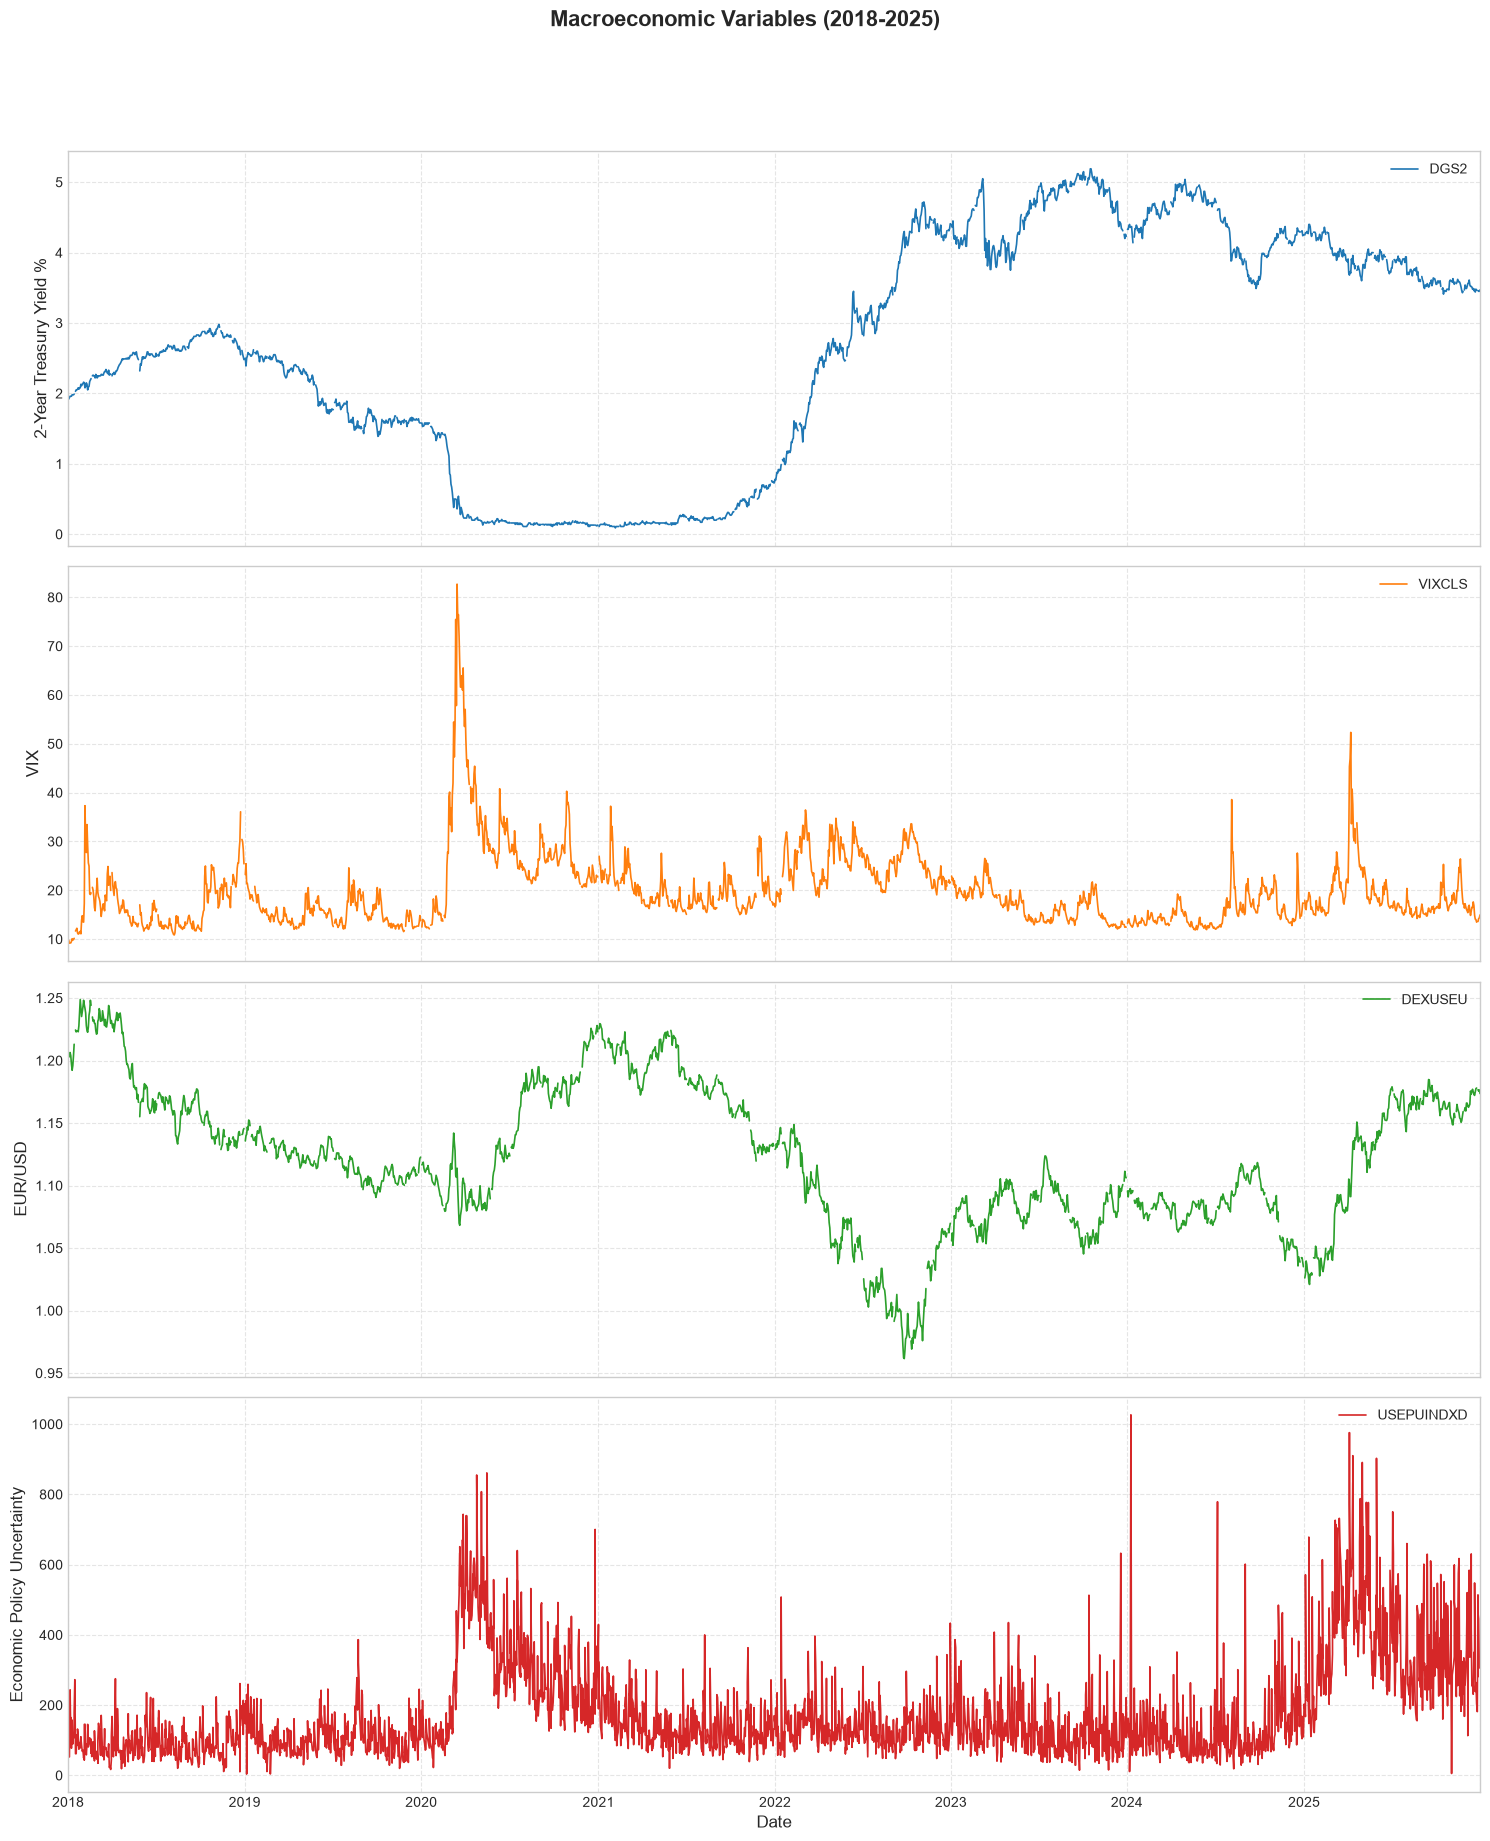

In [59]:
# Create time series plots for each dataset

plt.style.use('seaborn-v0_8-whitegrid')

fig, axes = plt.subplots(4, 1, figsize=(15, 18), sharex=True)

dgs2.plot(ax=axes[0], color='tab:blue', linewidth=1.2)
vix.plot(ax=axes[1], color='tab:orange', linewidth=1.2)
eurusd.plot(ax=axes[2], color='tab:green', linewidth=1.2)
epu.plot(ax=axes[3], color='tab:red', linewidth=1.2)

axes[0].set_ylabel('2-Year Treasury Yield %', fontsize=12)
axes[1].set_ylabel('VIX', fontsize=12)
axes[2].set_ylabel('EUR/USD', fontsize=12)
axes[3].set_ylabel('Economic Policy Uncertainty', fontsize=12)

axes[3].set_xlabel('Date', fontsize=12)

for ax in axes:
    ax.tick_params(axis='both', labelsize=10)
    ax.grid(True, linestyle='--', alpha=0.5)

plt.suptitle('Macroeconomic Variables (2018-2025)', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout(rect=[0, 0, 1, 0.97])
plt.show()

## 5. Visual Assessment of Stationarity

Prior to conducting formal statistical tests, the time series were visually inspected to assess whether they appear stationary.

- **DGS2:** Displays clear trends and changes in its mean level, suggesting non-stationarity.
- **VIX:** Appears to fluctuate around a relatively stable long-run mean despite periods of elevated volatility, making it a plausible candidate for stationarity.
- **EUR/USD:** Exhibits characteristics of a random walk, suggesting that the series is non-stationary.
- **EPU:** Contains substantial spikes and possible regime shifts. Visual inspection alone is insufficient to determine stationarity, therefore a formal ADF test is required.  

## 6. Augmented Dickey-Fuller (ADF) Test

The Augmented Dickey-Fuller (ADF) test is a statistical test used to determine whether a time series is stationary. Stationarity is an important assumption for Vector Autoregressive (VAR) and VAR-X models, as non-stationary variables can lead to misleading regression results.

The hypotheses of the ADF test are:
- **Null Hypothesis ($H_0$):** The time series contains a unit root and is non-stationary.
- **Alternative Hypothesis ($H_1$):** The time series is stationary.

A significance level of **5% ($\alpha = 0.05$)** is adopted throughout this analysis.

- If the **$p$-value $<$ 0.05**, the null hypothesis is rejected and the series is considered stationary.
- If the **$p$-value $\geq$ 0.05**, the null hypothesis cannot be rejected, indicating that the series is likely non-stationary and may require transformation before being included in the VAR-X model.

The ADF test is applied to each of the four macroeconomic control variables to determine whether they are stationary in levels or whether transformations, such as first differences or log returns, are required before they can be included in the VAR-X model.

In [60]:
# Starting with DGS2, we will run the Augmented Dickey-Fuller (ADF) test to check for stationarity. 

adf_dgs2 = adfuller(dgs2["DGS2"].dropna())

print("========== DGS2 ==========")
print("ADF statistic (DGS2):", adf_dgs2[0])
print("p-value (DGS2):", adf_dgs2[1])
print("Number of lags used (DGS2):", adf_dgs2[2])
print("Number of observations (DGS2):", adf_dgs2[3])
print("Critical values (DGS2):")
for key, value in adf_dgs2[4].items():
    print(f"   {key}: {value:.3f}")

========== DGS2 ==========
ADF statistic (DGS2): -0.8514478092751347
p-value (DGS2): 0.8035408182179483
Number of lags used (DGS2): 18
Number of observations (DGS2): 1980
Critical values (DGS2):
   1%: -3.434
   5%: -2.863
   10%: -2.568




Since the $p$-value (0.80) is greater than the 5% significance level, we fail to reject the null hypothesis that the series contains a unit root. Therefore, there is insufficient evidence to conclude that DGS2 is stationary, supporting our initial visual assessment that the series is non-stationary.

In [61]:
# We first run an ADF test on the VIX index to check for stationarity.

adf_vix = adfuller(vix["VIXCLS"].dropna())

print("========== VIX ==========")
print("ADF statistic (VIX):", adf_vix[0])
print("p-value (VIX):", adf_vix[1])
print("Number of lags used (VIX):", adf_vix[2])
print("Number of observations (VIX):", adf_vix[3])
print("Critical values (VIX):")
for key, value in adf_vix[4].items():
    print(f"   {key}: {value:.3f}")


# Next we run an ADF test on the EUR/USD exchange rate to check for stationarity.

adf_eurusd = adfuller(eurusd["DEXUSEU"].dropna())

print("========== EUR/USD ==========")
print("ADF statistic (EUR/USD):", adf_eurusd[0])
print("p-value (EUR/USD):", adf_eurusd[1])
print("Number of lags used (EUR/USD):", adf_eurusd[2])
print("Number of observations (EUR/USD):", adf_eurusd[3])
print("Critical values (EUR/USD):")
for key, value in adf_eurusd[4].items():
    print(f"   {key}: {value:.3f}")

# Finally, we run an ADF test on the Economic Policy Uncertainty index to check for stationarity.

adf_epu = adfuller(epu["USEPUINDXD"].dropna())

print("========== EPU ==========")
print("ADF statistic (EPU):", adf_epu[0])
print("p-value (EPU):", adf_epu[1])
print("Number of lags used (EPU):", adf_epu[2])
print("Number of observations (EPU):", adf_epu[3])
print("Critical values (EPU):")
for key, value in adf_epu[4].items():
    print(f"   {key}: {value:.3f}") 



========== VIX ==========
ADF statistic (VIX): -5.21911465923229
p-value (VIX): 8.035499060053718e-06
Number of lags used (VIX): 9
Number of observations (VIX): 2028
Critical values (VIX):
   1%: -3.434
   5%: -2.863
   10%: -2.568
========== EUR/USD ==========
ADF statistic (EUR/USD): -2.207366162729721
p-value (EUR/USD): 0.20358283595418503
Number of lags used (EUR/USD): 1
Number of observations (EUR/USD): 1995
Critical values (EUR/USD):
   1%: -3.434
   5%: -2.863
   10%: -2.568
========== EPU ==========
ADF statistic (EPU): -2.115439579599861
p-value (EPU): 0.2383517599967268
Number of lags used (EPU): 27
Number of observations (EPU): 2894
Critical values (EPU):
   1%: -3.433
   5%: -2.863
   10%: -2.567


## Interpretation

Based on the p-values obtained from the ADF tests, only the VIX is stationary in levels and can therefore be included in the VAR-X model without further transformation. For DGS2, EUR/USD and the Economic Policy Uncertainty (EPU) Index, the null hypothesis of a unit root cannot be rejected, indicating that these variables are non-stationary in their current form.

The next step is to identify suitable transformations for each non-stationary variable. A natural starting point is to apply first differences to DGS2 and EPU, while using log returns for the EUR/USD spot exchange rate. The transformed series will then be tested again using the ADF test to verify whether stationarity has been achieved.

Once stationary versions of all variables have been obtained, the macroeconomic control variables extracted from FRED will be ready for inclusion as exogenous variables in the VAR-X model.

## 7. Variable Transformations

Since the results from the ADF tests indicate that DGS2, EUR/USD and EPU are non-stationary in levels, transformations are needed to achieve stationarity before the variables can be used in the VAR-X model.

For DGS2 and EPU, first differences are considered. For EUR/USD, log returns are considered, as exchange rate levels often behave like random walks and are commonly modelled using returns in empirical finance.

After transforming each series, the ADF test is applied again to check whether stationarity has been achieved.


In [62]:
# First we apply first difference on the DGS2 data

dgs2_diff = dgs2["DGS2"].diff().dropna()

# And right after we perform an ADF test on the transformed dataset

adf_dgs2_diff = adfuller(dgs2_diff)

print("========== DGS2 First Difference ==========")
print("ADF statistic:", adf_dgs2_diff[0])
print("p-value:", adf_dgs2_diff[1])
print("Number of lags used:", adf_dgs2_diff[2])
print("Number of observations:", adf_dgs2_diff[3])
print("Critical values:")
for key, value in adf_dgs2_diff[4].items():
    print(f"   {key}: {value:.3f}")


# We perform the exact same process on EPU 

epu_diff = epu["USEPUINDXD"].diff().dropna()

adf_epu_diff = adfuller(epu_diff)

print("========== EPU First Difference ==========")
print("ADF statistic:", adf_epu_diff[0])
print("p-value:", adf_epu_diff[1])
print("Number of lags used:", adf_epu_diff[2])
print("Number of observations:", adf_epu_diff[3])
print("Critical values:")
for key, value in adf_epu_diff[4].items():
    print(f"   {key}: {value:.3f}")

========== DGS2 First Difference ==========
ADF statistic: -8.552791575870106
p-value: 9.127114846131991e-14
Number of lags used: 17
Number of observations: 1892
Critical values:
   1%: -3.434
   5%: -2.863
   10%: -2.568
========== EPU First Difference ==========
ADF statistic: -17.058053886288643
p-value: 7.982781795394961e-30
Number of lags used: 26
Number of observations: 2894
Critical values:
   1%: -3.433
   5%: -2.863
   10%: -2.567


In [63]:
# Now we transform the EUR/USD Exchange Spot Rate using the logarithm of returns

eurusd_log_return = np.log(eurusd["DEXUSEU"]).diff().dropna()

# And we test for stationarity using ADF 

adf_eurusd_log_return = adfuller(eurusd_log_return)

print("========== EUR/USD Log Returns ==========")
print("ADF statistic:", adf_eurusd_log_return[0])
print("p-value:", adf_eurusd_log_return[1])
print("Number of lags used:", adf_eurusd_log_return[2])
print("Number of observations:", adf_eurusd_log_return[3])
print("Critical values:")
for key, value in adf_eurusd_log_return[4].items():
    print(f"   {key}: {value:.3f}")

========== EUR/USD Log Returns ==========
ADF statistic: -42.30998137128636
p-value: 0.0
Number of lags used: 0
Number of observations: 1908
Critical values:
   1%: -3.434
   5%: -2.863
   10%: -2.568


## Interpretation

As we can see from the results above, by transforming each variable's dataset as above, after we run an ADF test we achieve a p-value that is less than 0.05, as was required by our initial ADF test previously. The transformed series all produce p-values below the 5% significance level, allowing us to reject the null hypothesis of a unit root. This provides evidence that the transformed variables are stationary and therefore suitable for inclusion in the VAR-X model.

Therefore, via using the transformations above on the datasets we exported from FRED we now have four stationary macroeconomic variables that are ready to be used in a VAR-X model.

# 8. Next Steps

The exogenous macroeconomic control variables have now been imported, explored, tested for stationarity and, where necessary, transformed to obtain stationary series suitable for inclusion in the VAR-X model.

The remaining step before model construction is to obtain the Cross-Currency Basis (CCB) data and determine whether the dependent variable also requires transformation prior to estimation.

## Questions for discussion

- Will Bloomberg Terminal be the primary source used to obtain the CCB data, or is there an alternative database that you would recommend?
- For the EUR/USD exchange rate, would you recommend using log returns or first differences within the VAR-X model?
- Would you recommend documenting the methodology and progress in a separate Overleaf report throughout the project, or is maintaining a well-documented Jupyter notebook sufficient at this stage?
